# k-means

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2,
                  random_state=23)

In [3]:
X.shape

(1000, 2)

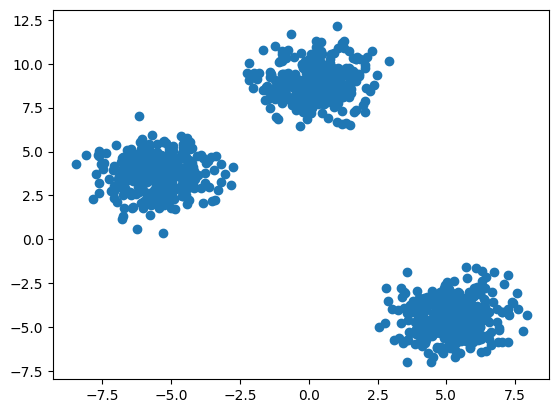

In [4]:
plt.scatter(X[:,0],X[:,1])

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [6]:
from sklearn.cluster import KMeans

In [7]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,init = 'k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [8]:
wcss

[34827.57682552023,
 7935.43728614542,
 1319.2730531585605,
 1140.4677884655127,
 1048.7401198526404,
 908.9042971963779,
 771.2672451086938,
 670.8947232212311,
 581.0217780743483,
 563.386332138139]

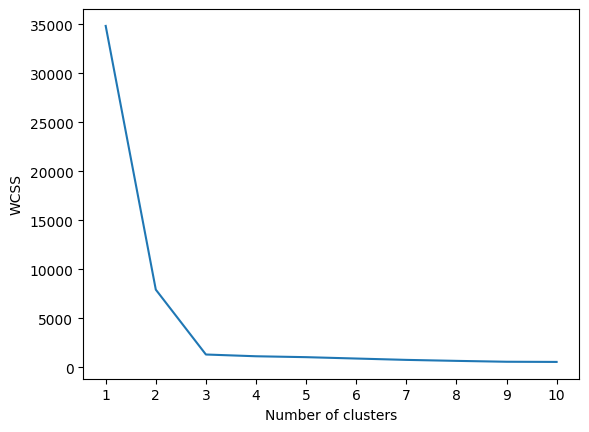

In [9]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
kmeans = KMeans(n_clusters = 3,init = "k-means++")

In [11]:
y_labels = kmeans.fit_predict(X_train)

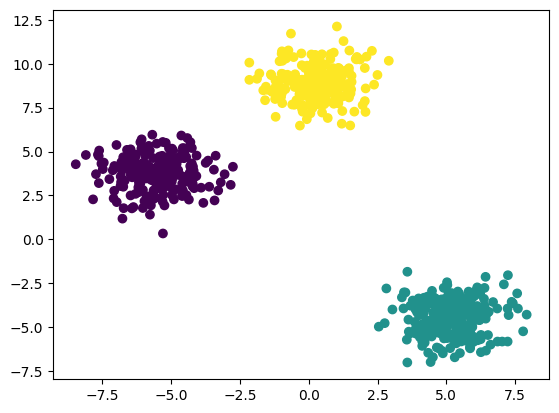

In [12]:
plt.scatter(X_train[:,0],X_train[:,1],c = y_labels)

In [13]:
y_test_label = kmeans.predict(X_test)

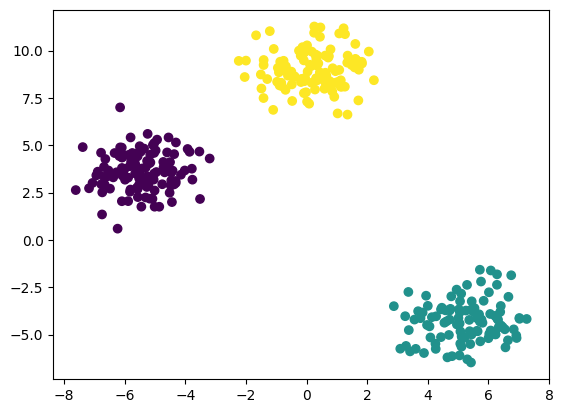

In [14]:
plt.scatter(X_test[:,0],X_test[:,1],c = y_test_label)

# kneed

In [15]:
import sys
!{sys.executable} -m pip install kneed

from kneed import KneeLocator

kl = KneeLocator(range(1,11),wcss,curve = 'convex',direction='decreasing')
kl.elbow

np.int64(3)

# performance matrix

In [16]:
from sklearn.metrics import silhouette_score

In [17]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k,init = "k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [18]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797673,
 0.6593671074925264,
 0.4741797015795316,
 0.3027387063856045,
 0.3425105292800712,
 0.3493691801021937,
 0.34651811680098216,
 0.33584228434363245]

([<matplotlib.axis.XTick at 0x1323eb8d0>,
 [Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

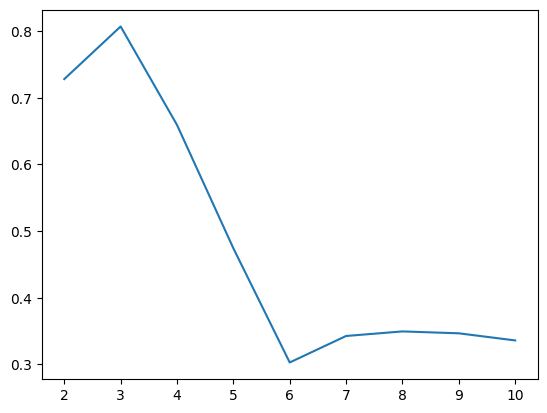

In [19]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))